# 📦 Notebook 1: Data Preparation
## Prompted Segmentation for Drywall QA

This notebook handles **all data downloading and preprocessing** before fine-tuning CLIPSeg.

### What this notebook does:
1. Installs required libraries
2. Downloads Dataset 1 → **Drywall taping area** (821 images) from Roboflow
3. Downloads Dataset 2 → **Wall cracks** (2871 images) from Roboflow
4. Converts annotations to **binary PNG masks**:
   - Dataset 1 has **bounding box labels only** (detection dataset) → converted to filled rectangle masks
   - Dataset 2 has **polygon segmentation labels** → converted to precise polygon masks
5. Assigns **text prompts** to each dataset
6. Organizes everything into a clean folder structure
7. Verifies the data with visual samples

### ⚠️ Important Note on Dataset 1 (Taping):
> `drywall-join-detect` is an **object detection dataset** — it only has bounding box annotations,
> not polygon segmentation masks. We convert bounding boxes to filled rectangular binary masks
> as ground truth proxies. This is standard practice and is documented in the report.

### Output folder structure:
```
data/
  train/
    images/        <- source images
    masks/         <- binary masks {0,255} single channel PNG
    prompts.json   <- {image_filename: prompt_text}
  val/
    images/
    masks/
    prompts.json
  test/
    images/
    masks/
    prompts.json
  dataset_info.json  <- read by Notebook 2
```

---
> DEBUG_MODE = True  runs on 20 images per dataset to verify pipeline quickly.
> Set to False for full training run.

## Step 0: Configuration

In [ ]:
import os
# =============================================================
# CONFIGURATION
# =============================================================

# DEBUG MODE
# True  -> only 20 images per dataset (fast pipeline check)
# False -> full dataset
DEBUG_MODE     = False
DEBUG_SAMPLES  = 20

# RANDOM SEED
SEED = 42

# ROBOFLOW API KEY
# Get from: https://app.roboflow.com -> Settings -> API
ROBOFLOW_API_KEY = "LhWVjuFZY7MUjPMuJAjA"

# OUTPUT DIRECTORY
DATA_ROOT = "./data"

# TEXT PROMPTS
# These exact strings are passed to CLIPSeg during training
PROMPT_TAPING = "segment taping area"
PROMPT_CRACK  = "segment crack"

print(f"{'='*50}")
print(f"DEBUG_MODE  : {DEBUG_MODE}")
print(f"SEED        : {SEED}")
print(f"Data root   : {DATA_ROOT}")
print(f"Prompt 1    : '{PROMPT_TAPING}'")
print(f"Prompt 2    : '{PROMPT_CRACK}'")
print(f"{'='*50}")
print(ROBOFLOW_API_KEY)

DEBUG_MODE  : False
SEED        : 42
Data root   : ./data
Prompt 1    : 'segment taping area'
Prompt 2    : 'segment crack'
LhWVjuFZY7MUjPMuJAjA


## Step 1: Install Dependencies

In [ ]:
!pip install -q roboflow Pillow numpy matplotlib tqdm opencv-python-headless
print("All packages installed.")

All packages installed.


## Step 2: Imports

In [ ]:
import os
import json
import shutil
import random
import numpy as np
from pathlib import Path
from PIL import Image, ImageDraw
from tqdm import tqdm
import matplotlib.pyplot as plt
from roboflow import Roboflow

random.seed(SEED)
np.random.seed(SEED)

print("Imports done. Seeds fixed at:", SEED)

Imports done. Seeds fixed at: 42


## Step 3: Helper Functions

Key function here is `parse_yolo_label_auto` which auto-detects
whether a label file has bounding boxes (5 tokens per line) or
segmentation polygons (7+ tokens per line) and handles both.

- Dataset 1 (taping)  -> 5 tokens -> bbox -> filled rectangle mask
- Dataset 2 (cracks)  -> 7+ tokens -> polygon -> precise mask

In [ ]:
def create_dir_structure(root: str) -> None:
    """
    Creates output folder structure for train/val/test splits.

    Args:
        root (str): Root directory path e.g './data'

    Returns:
        None
    """
    for split in ["train", "val", "test"]:
        for sub in ["images", "masks"]:
            Path(root, split, sub).mkdir(parents=True, exist_ok=True)
    print(f"Directory structure created at: {root}")


def polygon_to_binary_mask(polygons: list, img_w: int, img_h: int) -> np.ndarray:
    """
    Converts normalized polygon coordinates into a binary mask.
    Used for Dataset 2 (cracks) which has proper segmentation annotations.

    Args:
        polygons (list): List of polygons. Each polygon is [[x1,y1],[x2,y2],...]
                         with coordinates normalized to [0.0, 1.0].
        img_w (int): Image width in pixels.
        img_h (int): Image height in pixels.

    Returns:
        np.ndarray: Binary mask shape (img_h, img_w), dtype uint8, values {0, 255}.
    """
    mask = Image.new("L", (img_w, img_h), 0)
    draw = ImageDraw.Draw(mask)
    for poly in polygons:
        pixel_coords = [(int(x * img_w), int(y * img_h)) for x, y in poly]
        if len(pixel_coords) >= 3:
            draw.polygon(pixel_coords, fill=255)
    return np.array(mask)


def bbox_to_binary_mask(cx: float, cy: float, bw: float, bh: float,
                         img_w: int, img_h: int) -> np.ndarray:
    """
    Converts a YOLO bounding box into a filled rectangle binary mask.
    Used for Dataset 1 (taping area) which only has bounding box annotations.

    The entire region inside the box is marked as foreground (255).
    This is a valid approximation: the taping area IS the region inside the box.
    Limitation is documented in the report.

    Args:
        cx (float): Normalized center x [0.0, 1.0].
        cy (float): Normalized center y [0.0, 1.0].
        bw (float): Normalized box width [0.0, 1.0].
        bh (float): Normalized box height [0.0, 1.0].
        img_w (int): Image width in pixels.
        img_h (int): Image height in pixels.

    Returns:
        np.ndarray: Binary mask shape (img_h, img_w), dtype uint8, values {0, 255}.
    """
    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    x1 = int((cx - bw / 2) * img_w)
    y1 = int((cy - bh / 2) * img_h)
    x2 = int((cx + bw / 2) * img_w)
    y2 = int((cy + bh / 2) * img_h)
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img_w, x2), min(img_h, y2)
    mask[y1:y2, x1:x2] = 255
    return mask


def parse_yolo_label_auto(label_path: str, img_w: int, img_h: int) -> np.ndarray:
    """
    Auto-detects YOLO label format and converts to binary mask.

    Detection format  (5 tokens per line): class cx cy w h
        -> calls bbox_to_binary_mask -> filled rectangle

    Segmentation format (7+ tokens per line): class x1 y1 x2 y2 x3 y3 ...
        -> calls polygon_to_binary_mask -> precise polygon mask

    This single function correctly handles BOTH datasets automatically.

    Args:
        label_path (str): Path to the YOLO .txt label file.
        img_w (int): Image width in pixels.
        img_h (int): Image height in pixels.

    Returns:
        np.ndarray: Binary mask shape (img_h, img_w), dtype uint8, values {0, 255}.
                    Returns all-zero mask if file not found or empty.
    """
    mask = np.zeros((img_h, img_w), dtype=np.uint8)

    if not os.path.exists(label_path):
        return mask

    with open(label_path, 'r') as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    for line in lines:
        parts = line.split()

        if len(parts) == 5:
            # BOUNDING BOX: class_id cx cy width height
            _, cx, cy, bw, bh = map(float, parts)
            layer = bbox_to_binary_mask(cx, cy, bw, bh, img_w, img_h)

        elif len(parts) >= 7:
            # SEGMENTATION POLYGON: class_id x1 y1 x2 y2 x3 y3 ...
            coords  = list(map(float, parts[1:]))
            polygon = [(coords[i], coords[i+1]) for i in range(0, len(coords)-1, 2)]
            layer   = polygon_to_binary_mask([polygon], img_w, img_h)

        else:
            continue  # skip malformed lines

        # Merge multiple objects in same image
        mask = np.maximum(mask, layer)

    return mask


def save_mask(mask: np.ndarray, save_path: str) -> None:
    """
    Saves binary numpy array as single-channel PNG.

    Args:
        mask (np.ndarray): Binary mask shape (H, W), values {0, 255}.
        save_path (str): Full path to save the PNG.

    Returns:
        None
    """
    Image.fromarray(mask.astype(np.uint8), mode='L').save(save_path)


print("Helper functions defined.")
print("parse_yolo_label_auto handles: bbox (5 tokens) AND polygon (7+ tokens)")

Helper functions defined.
parse_yolo_label_auto handles: bbox (5 tokens) AND polygon (7+ tokens)


## Step 4: Download Datasets from Roboflow

In [ ]:
def download_roboflow_dataset(api_key: str, workspace: str, project: str,
                               version: int, fmt: str, save_dir: str) -> str:
    """
    Downloads a dataset from Roboflow Universe.

    Args:
        api_key (str): Your Roboflow API key.
        workspace (str): Roboflow workspace slug.
        project (str): Roboflow project slug.
        version (int): Dataset version number.
        fmt (str): Export format ('yolov8' works for both detection and segmentation).
        save_dir (str): Local path to save the dataset.

    Returns:
        str: Path to the downloaded dataset folder.
    """
    rf      = Roboflow(api_key=api_key)
    dataset = rf.workspace(workspace).project(project).version(version)
    dataset.download(fmt, location=save_dir)
    print(f"Downloaded: {workspace}/{project} v{version} -> {save_dir}")
    return save_dir


print("Downloading Dataset 1: Drywall taping area...")
taping_raw_dir = download_roboflow_dataset(
    api_key   = ROBOFLOW_API_KEY,
    workspace = "objectdetect-pu6rn",
    project   = "drywall-join-detect",
    version   = 1,
    fmt       = "yolov8",
    save_dir  = "./raw/taping"
)

print("\nDownloading Dataset 2: Wall cracks...")
crack_raw_dir = download_roboflow_dataset(
    api_key   = ROBOFLOW_API_KEY,
    workspace = "a-edvno",
    project   = "wall-crack-yccht-iajnn",
    version   = 1,
    fmt       = "yolov8",
    save_dir  = "./raw/crack"
)

print("\nBoth datasets downloaded.")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ./raw/taping in yolov8:: 100%|██████████| 2381/2381 [00:00<00:00, 2539.54it/s]


Downloaded: objectdetect-pu6rn/drywall-join-detect v1 -> ./raw/taping

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ./raw/crack in yolov8:: 100%|██████████| 7286/7286 [00:01<00:00, 3927.55it/s]

Downloaded: a-edvno/wall-crack-yccht-iajnn v1 -> ./raw/crack

Both datasets downloaded.


## Step 5: Inspect Raw Datasets + Confirm Label Formats

This step confirms:
- Dataset 1 (taping) -> 5 tokens per line = bbox only
- Dataset 2 (cracks) -> 7+ tokens per line = segmentation polygons

In [ ]:
def inspect_dataset(raw_dir: str, name: str) -> None:
    """
    Prints dataset summary and confirms label format.
    Shows token count to distinguish detection vs segmentation labels.

    Args:
        raw_dir (str): Path to the downloaded dataset folder.
        name (str): Display name for the dataset.

    Returns:
        None
    """
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    for split in ["train", "valid", "test"]:
        img_dir   = Path(raw_dir) / split / "images"
        label_dir = Path(raw_dir) / split / "labels"
        n_imgs    = len(list(img_dir.glob("*")))   if img_dir.exists()   else 0
        n_labels  = len(list(label_dir.glob("*"))) if label_dir.exists() else 0
        print(f"  {split:6s}: {n_imgs:4d} images | {n_labels:4d} labels")

    label_dir = Path(raw_dir) / "train" / "labels"
    if label_dir.exists():
        samples = list(label_dir.glob("*.txt"))[:1]
        if samples:
            with open(samples[0]) as f:
                first_line = f.readline().strip()
            n_tokens = len(first_line.split())
            fmt = "BBOX only (detection)" if n_tokens == 5 \
                  else f"SEGMENTATION polygon ({n_tokens} tokens)"
            print(f"\n  Sample label : {first_line[:70]}")
            print(f"  Token count  : {n_tokens} -> {fmt}")


inspect_dataset(taping_raw_dir, "Dataset 1: Drywall Taping")
inspect_dataset(crack_raw_dir,  "Dataset 2: Wall Cracks")


Dataset 1: Drywall Taping
  train :  936 images |  936 labels
  valid :  250 images |  250 labels
  test  :    0 images |    0 labels

  Sample label : 0 0.5109375 0.54453125 0.6109375 0.025
  Token count  : 5 -> BBOX only (detection)

Dataset 2: Wall Cracks
  train : 2870 images | 2870 labels
  valid :  523 images |  523 labels
  test  :  244 images |  244 labels

  Sample label : 0 0.16171875 0.4296875 0.45390625 0.4296875 0.45390625 1 0.16171875 1
  Token count  : 9 -> SEGMENTATION polygon (9 tokens)


## Step 6: Clear Old Processed Data (if re-running)

In [ ]:
# Clears ./data/ only — raw downloads in ./raw/ are kept
# so you don't need to re-download on re-runs

if Path(DATA_ROOT).exists():
    shutil.rmtree(DATA_ROOT)
    print(f"Cleared old processed data at {DATA_ROOT}")
else:
    print(f"No existing data to clear at {DATA_ROOT}")

create_dir_structure(DATA_ROOT)

No existing data to clear at ./data
Directory structure created at: ./data


## Step 7: Build Unified Dataset

In [ ]:
def build_unified_dataset(raw_dir: str, prompt: str, dataset_tag: str,
                           out_root: str, debug: bool = False,
                           debug_n: int = 20, seed: int = 42) -> dict:
    """
    Processes one raw Roboflow dataset into the unified training format.

    For each image:
      1. Copies image to out_root/{split}/images/{tag}_{name}
      2. Parses label (auto-detects bbox vs polygon via parse_yolo_label_auto)
      3. Saves binary PNG mask to out_root/{split}/masks/{tag}_{name}.png
      4. Records {filename: prompt} in prompts.json

    Naming: {dataset_tag}_{original_stem} prevents filename collisions.
    Example: 'crack_img001.jpg', 'tape_img001.jpg'

    Args:
        raw_dir (str): Path to raw Roboflow download folder.
        prompt (str): Text prompt for this dataset e.g 'segment crack'.
        dataset_tag (str): Short prefix: 'crack' or 'tape'.
        out_root (str): Root output directory e.g './data'.
        debug (bool): If True only process debug_n images per split.
        debug_n (int): Number of images per split in debug mode.
        seed (int): Random seed for debug subset selection.

    Returns:
        dict: {'train': N, 'val': N, 'test': N} count of processed images per split.
    """
    random.seed(seed)
    split_map = {"train": "train", "valid": "val", "test": "test"}
    counts    = {}

    for raw_split, out_split in split_map.items():
        img_dir   = Path(raw_dir) / raw_split / "images"
        label_dir = Path(raw_dir) / raw_split / "labels"

        if not img_dir.exists():
            print(f"  {raw_split} split not found - skipping.")
            counts[out_split] = 0
            continue

        out_img_dir  = Path(out_root) / out_split / "images"
        out_mask_dir = Path(out_root) / out_split / "masks"

        image_files = sorted([
            p for p in img_dir.glob("*")
            if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
        ])

        if debug:
            image_files = random.sample(image_files, min(debug_n, len(image_files)))
            print(f"  DEBUG: {len(image_files)} images for {raw_split}")

        prompt_map = {}

        for img_path in tqdm(image_files, desc=f"  {dataset_tag}/{out_split}"):
            stem     = img_path.stem
            new_stem = f"{dataset_tag}_{stem}"

            # Copy image
            dst_img = out_img_dir / f"{new_stem}{img_path.suffix}"
            shutil.copy2(img_path, dst_img)

            # Generate mask (auto bbox or polygon)
            label_path   = label_dir / f"{stem}.txt"
            img_pil      = Image.open(img_path)
            img_w, img_h = img_pil.size
            mask = parse_yolo_label_auto(str(label_path), img_w, img_h)

            # Save mask
            save_mask(mask, str(out_mask_dir / f"{new_stem}.png"))

            # Record prompt
            prompt_map[f"{new_stem}{img_path.suffix}"] = prompt

        # Append to prompts.json (merges both datasets into same file)
        prompt_file = Path(out_root) / out_split / "prompts.json"
        existing    = json.load(open(prompt_file)) if prompt_file.exists() else {}
        existing.update(prompt_map)
        with open(prompt_file, 'w') as f:
            json.dump(existing, f, indent=2)

        counts[out_split] = len(image_files)
        print(f"  {out_split}: {len(image_files)} samples processed")

    return counts


# Dataset 1: Taping -> bbox -> rectangle masks
print("Processing Dataset 1 - Taping (bbox -> rectangle masks)...")
taping_counts = build_unified_dataset(
    raw_dir=taping_raw_dir, prompt=PROMPT_TAPING, dataset_tag="tape",
    out_root=DATA_ROOT, debug=DEBUG_MODE, debug_n=DEBUG_SAMPLES, seed=SEED
)

# Dataset 2: Cracks -> polygon -> precise masks
print("\nProcessing Dataset 2 - Cracks (polygon -> precise masks)...")
crack_counts = build_unified_dataset(
    raw_dir=crack_raw_dir, prompt=PROMPT_CRACK, dataset_tag="crack",
    out_root=DATA_ROOT, debug=DEBUG_MODE, debug_n=DEBUG_SAMPLES, seed=SEED
)

Processing Dataset 1 - Taping (bbox -> rectangle masks)...


  tape/train: 100%|██████████| 936/936 [00:06<00:00, 134.24it/s]


  train: 936 samples processed


  tape/val: 100%|██████████| 250/250 [00:01<00:00, 194.02it/s]


  val: 250 samples processed
  test split not found - skipping.

Processing Dataset 2 - Cracks (polygon -> precise masks)...


...

  train: 2870 samples processed


  crack/val: 100%|██████████| 523/523 [00:03<00:00, 146.46it/s]


  val: 523 samples processed


  crack/test: 100%|██████████| 244/244 [00:01<00:00, 168.41it/s]

  test: 244 samples processed


## Step 8: Dataset Summary + Integrity Check

In [ ]:
def print_split_summary(data_root: str) -> None:
    """
    Prints summary table of images, masks, and prompts per split.
    Integrity check: every image must have exactly one mask and one prompt entry.

    Args:
        data_root (str): Root directory of the unified dataset.

    Returns:
        None
    """
    print("\n" + "="*58)
    print(f"{'SPLIT':<8} {'IMAGES':>8} {'MASKS':>8} {'PROMPTS':>10} {'OK?':>6}")
    print("="*58)
    for split in ["train", "val", "test"]:
        img_dir  = Path(data_root) / split / "images"
        mask_dir = Path(data_root) / split / "masks"
        pfile    = Path(data_root) / split / "prompts.json"
        n_img    = len(list(img_dir.glob("*")))  if img_dir.exists()  else 0
        n_mask   = len(list(mask_dir.glob("*"))) if mask_dir.exists() else 0
        n_prom   = len(json.load(open(pfile)))   if pfile.exists()    else 0
        ok       = "OK" if n_img == n_mask == n_prom else "MISMATCH"
        print(f"{split:<8} {n_img:>8} {n_mask:>8} {n_prom:>10} {ok:>10}")
    print("="*58)


print_split_summary(DATA_ROOT)


SPLIT      IMAGES    MASKS    PROMPTS    OK?
train        3806     3806       3806         OK
val           773      773        773         OK
test          244      244        244         OK


## Step 9: Visual Verification

Expected output:
- Taping samples  -> rectangular filled masks
- Crack samples   -> thin irregular polygon masks

If taping masks are still black -> something went wrong with label parsing.

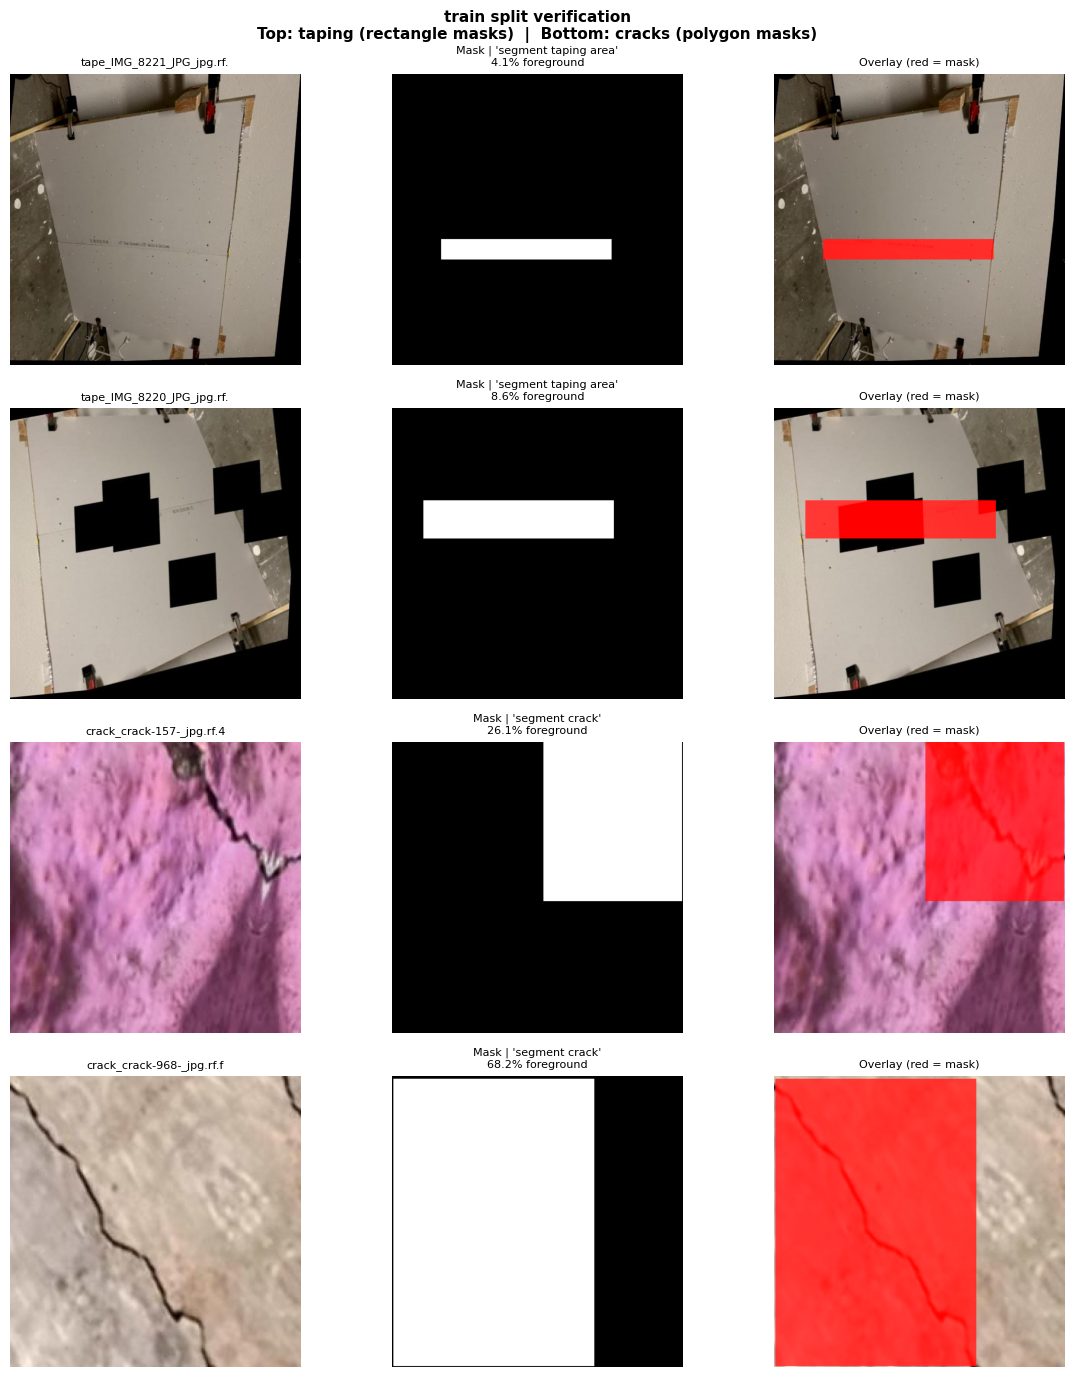

Saved to ./data/verification_train.png


In [ ]:
def visualize_samples(data_root: str, split: str = "train",
                       n_per_prompt: int = 2, seed: int = 42) -> None:
    """
    Displays sample images with their GT masks, grouped by dataset.
    Layout per row: Original Image | GT Mask | Overlay

    Args:
        data_root (str): Root directory of the unified dataset.
        split (str): Which split to sample from.
        n_per_prompt (int): Number of samples to show per dataset type.
        seed (int): Random seed for sample selection.

    Returns:
        None
    """
    random.seed(seed)
    img_dir  = Path(data_root) / split / "images"
    mask_dir = Path(data_root) / split / "masks"
    with open(Path(data_root) / split / "prompts.json") as f:
        prompts = json.load(f)

    tape_imgs  = list(img_dir.glob("tape_*"))
    crack_imgs = list(img_dir.glob("crack_*"))

    samples = (
        random.sample(tape_imgs,  min(n_per_prompt, len(tape_imgs))) +
        random.sample(crack_imgs, min(n_per_prompt, len(crack_imgs)))
    )

    n = len(samples)
    fig, axes = plt.subplots(n, 3, figsize=(12, 3.5 * n))
    if n == 1: axes = [axes]

    for i, img_path in enumerate(samples):
        img    = np.array(Image.open(img_path).convert("RGB"))
        maskp  = mask_dir / f"{img_path.stem}.png"
        mask   = np.array(Image.open(maskp).convert("L")) if maskp.exists() \
                 else np.zeros(img.shape[:2], np.uint8)
        prompt = prompts.get(img_path.name, "unknown")

        overlay = img.copy()
        overlay[mask > 0, 0] = 255
        overlay[mask > 0, 1] = (overlay[mask > 0, 1] * 0.3).astype(np.uint8)
        overlay[mask > 0, 2] = (overlay[mask > 0, 2] * 0.3).astype(np.uint8)

        pct = (mask > 0).mean() * 100
        axes[i][0].imshow(img)
        axes[i][0].set_title(img_path.name[:25], fontsize=8)
        axes[i][1].imshow(mask, cmap='gray')
        axes[i][1].set_title(f"Mask | '{prompt}'\n{pct:.1f}% foreground", fontsize=8)
        axes[i][2].imshow(overlay)
        axes[i][2].set_title("Overlay (red = mask)", fontsize=8)
        for ax in axes[i]: ax.axis('off')

    plt.suptitle(
        f"{split} split verification\n"
        f"Top: taping (rectangle masks)  |  Bottom: cracks (polygon masks)",
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    save_path = f"{data_root}/verification_{split}.png"
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f"Saved to {save_path}")


visualize_samples(DATA_ROOT, split="train", n_per_prompt=2, seed=SEED)

## Step 10: Save Dataset Info for Notebook 2

In [ ]:
def save_dataset_info(data_root: str, debug_mode: bool, seed: int,
                       prompt_taping: str, prompt_crack: str) -> None:
    """
    Saves dataset metadata to dataset_info.json.
    This file is automatically read by Notebook 2 at the start of training.

    Args:
        data_root (str): Root directory of the unified dataset.
        debug_mode (bool): Whether DEBUG_MODE was active.
        seed (int): Random seed used.
        prompt_taping (str): Text prompt for taping dataset.
        prompt_crack (str): Text prompt for crack dataset.

    Returns:
        None
    """
    info = {
        "debug_mode"  : debug_mode,
        "seed"        : seed,
        "prompts"     : {"taping": prompt_taping, "crack": prompt_crack},
        "data_root"   : data_root,
        "notes": {
            "taping": "bbox-derived rectangle masks — detection dataset limitation",
            "crack"  : "polygon-derived precise masks — segmentation dataset"
        },
        "split_counts": {}
    }
    for split in ["train", "val", "test"]:
        img_dir = Path(data_root) / split / "images"
        info["split_counts"][split] = len(list(img_dir.glob("*"))) \
                                      if img_dir.exists() else 0

    out_path = Path(data_root) / "dataset_info.json"
    with open(out_path, 'w') as f:
        json.dump(info, f, indent=2)

    print("dataset_info.json saved:")
    print(json.dumps(info, indent=2))


save_dataset_info(
    data_root=DATA_ROOT, debug_mode=DEBUG_MODE, seed=SEED,
    prompt_taping=PROMPT_TAPING, prompt_crack=PROMPT_CRACK
)

print("\n" + "="*50)
print("Notebook 1 complete!")
print("Next: Run 02_finetune_clipseg.ipynb")
print("="*50)

dataset_info.json saved:
{
  "debug_mode": false,
  "seed": 42,
  "prompts": {
    "taping": "segment taping area",
    "crack": "segment crack"
  },
  "data_root": "./data",
  "notes": {
    "taping": "bbox-derived rectangle masks \u2014 detection dataset limitation",
    "crack": "polygon-derived precise masks \u2014 segmentation dataset"
  },
  "split_counts": {
    "train": 3806,
    "val": 773,
    "test": 244
  }
}

Notebook 1 complete!
Next: Run 02_finetune_clipseg.ipynb


DATA SANITY CHECK

[1] Folder structure...
    train/images: OK
    train/masks: OK
    val/images: OK
    val/masks: OK
    test/images: OK
    test/masks: OK

[2] Counts per split...
    SPLIT      IMAGES    MASKS    PROMPTS   MATCH?
    ----------------------------------------------
    train        3806     3806       3806       OK
    val           773      773        773       OK
    test          244      244        244       OK

[3] Image <-> Mask file pairing...
    train: OK (3806 pairs)
    val: OK (773 pairs)
    test: OK (244 pairs)

[4] Mask format (should be single-channel, values only 0 or 255)...
    train: OK (checked 50)
    val: OK (checked 50)
    test: OK (checked 50)

[5] Taping masks not empty (main fix check)...
    train: OK — all 30 have foreground pixels
    val: OK — all 30 have foreground pixels
    test: OK — all 0 have foreground pixels

[6] Crack masks not empty...
    train: OK — all 30 have foreground pixels
    val: OK — all 30 have foreground pixels

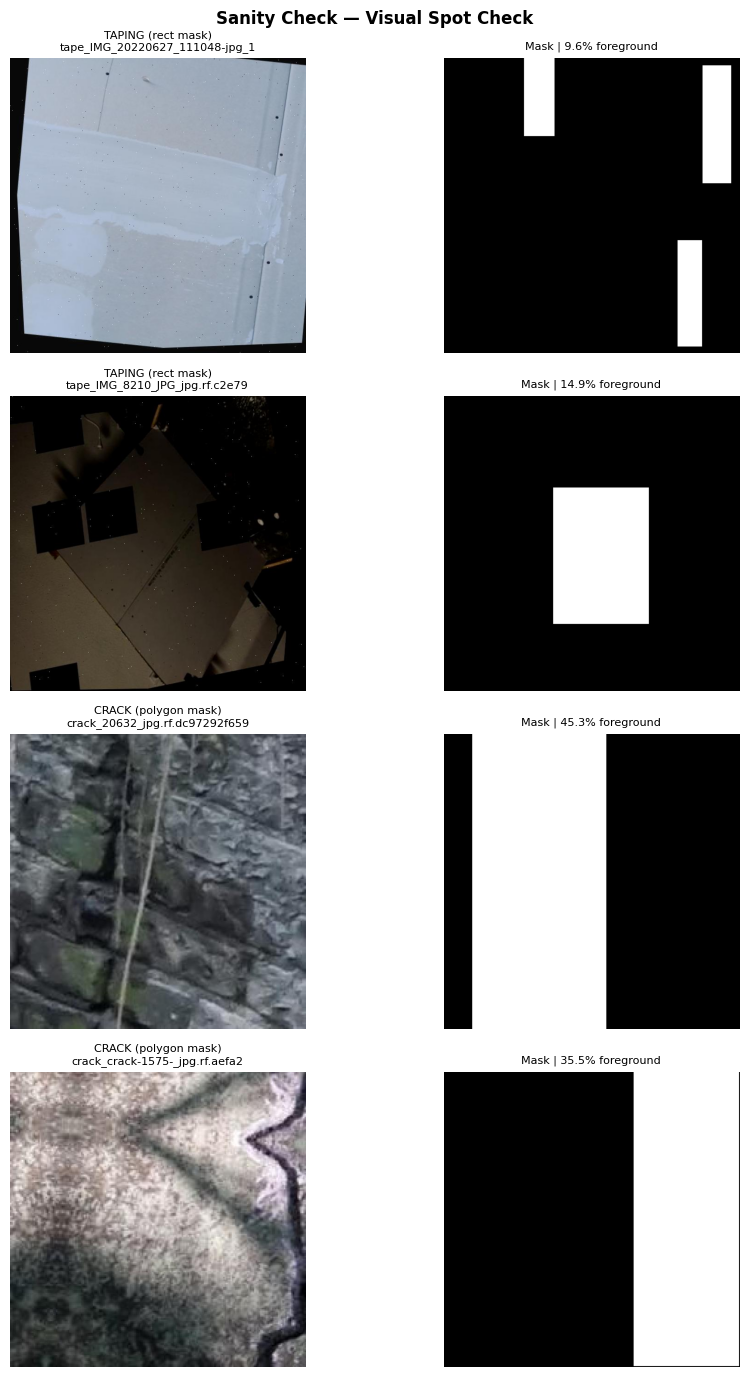


ISSUES FOUND (1):
  - test: missing prompt


In [ ]:
import json
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# =============================================================
# FULL DATA SANITY CHECK
# Run this after Notebook 1 to verify everything is correct
# =============================================================

DATA_ROOT = "./data"
ISSUES    = []

print("=" * 60)
print("DATA SANITY CHECK")
print("=" * 60)

# ----------------------------------------------------------
# CHECK 1: Folder structure exists
# ----------------------------------------------------------
print("\n[1] Folder structure...")
for split in ["train", "val", "test"]:
    for sub in ["images", "masks"]:
        p = Path(DATA_ROOT) / split / sub
        status = "OK" if p.exists() else "MISSING"
        if not p.exists(): ISSUES.append(f"Missing folder: {p}")
        print(f"    {split}/{sub}: {status}")

# ----------------------------------------------------------
# CHECK 2: Count images / masks / prompts per split
# ----------------------------------------------------------
print("\n[2] Counts per split...")
print(f"    {'SPLIT':<8} {'IMAGES':>8} {'MASKS':>8} {'PROMPTS':>10} {'MATCH?':>8}")
print(f"    {'-'*46}")
for split in ["train", "val", "test"]:
    img_dir  = Path(DATA_ROOT) / split / "images"
    mask_dir = Path(DATA_ROOT) / split / "masks"
    pfile    = Path(DATA_ROOT) / split / "prompts.json"
    n_img    = len(list(img_dir.glob("*")))  if img_dir.exists()  else 0
    n_mask   = len(list(mask_dir.glob("*"))) if mask_dir.exists() else 0
    n_prom   = len(json.load(open(pfile)))   if pfile.exists()    else 0
    match    = "OK" if n_img == n_mask == n_prom else "MISMATCH"
    if match != "OK": ISSUES.append(f"{split}: count mismatch img={n_img} mask={n_mask} prompt={n_prom}")
    print(f"    {split:<8} {n_img:>8} {n_mask:>8} {n_prom:>10} {match:>8}")

# ----------------------------------------------------------
# CHECK 3: Every image has a corresponding mask file
# ----------------------------------------------------------
print("\n[3] Image <-> Mask file pairing...")
for split in ["train", "val", "test"]:
    img_dir  = Path(DATA_ROOT) / split / "images"
    mask_dir = Path(DATA_ROOT) / split / "masks"
    missing  = []
    for img_path in img_dir.glob("*"):
        expected_mask = mask_dir / f"{img_path.stem}.png"
        if not expected_mask.exists():
            missing.append(img_path.name)
    status = f"OK ({len(list(img_dir.glob('*')))} pairs)" if not missing \
             else f"MISSING {len(missing)} masks"
    if missing: ISSUES.append(f"{split}: {len(missing)} images have no mask")
    print(f"    {split}: {status}")
    if missing[:3]: print(f"      e.g. {missing[:3]}")

# ----------------------------------------------------------
# CHECK 4: Mask format validation (single channel, values 0/255)
# ----------------------------------------------------------
print("\n[4] Mask format (should be single-channel, values only 0 or 255)...")
for split in ["train", "val", "test"]:
    mask_dir  = Path(DATA_ROOT) / split / "masks"
    bad_masks = []
    sample_masks = list(mask_dir.glob("*.png"))[:50]  # check first 50
    for mp in sample_masks:
        arr = np.array(Image.open(mp))
        if arr.ndim != 2:
            bad_masks.append(f"{mp.name}: {arr.ndim}D (expected 2D)")
        unique = set(np.unique(arr).tolist())
        if not unique.issubset({0, 255}):
            bad_masks.append(f"{mp.name}: values={unique}")
    status = f"OK (checked {len(sample_masks)})" if not bad_masks \
             else f"{len(bad_masks)} bad masks"
    if bad_masks: ISSUES.extend(bad_masks[:3])
    print(f"    {split}: {status}")

# ----------------------------------------------------------
# CHECK 5: Taping masks are NOT all black (main fix verification)
# ----------------------------------------------------------
print("\n[5] Taping masks not empty (main fix check)...")
for split in ["train", "val", "test"]:
    mask_dir   = Path(DATA_ROOT) / split / "masks"
    tape_masks = list(mask_dir.glob("tape_*.png"))[:30]
    empty      = [m.name for m in tape_masks
                  if np.array(Image.open(m)).max() == 0]
    total      = len(tape_masks)
    status = f"OK — all {total} have foreground pixels" if not empty \
             else f"EMPTY: {len(empty)}/{total} masks are all black"
    if empty: ISSUES.append(f"{split} taping: {len(empty)} empty masks")
    print(f"    {split}: {status}")

# ----------------------------------------------------------
# CHECK 6: Crack masks are NOT all black
# ----------------------------------------------------------
print("\n[6] Crack masks not empty...")
for split in ["train", "val", "test"]:
    mask_dir    = Path(DATA_ROOT) / split / "masks"
    crack_masks = list(mask_dir.glob("crack_*.png"))[:30]
    empty       = [m.name for m in crack_masks
                   if np.array(Image.open(m)).max() == 0]
    total       = len(crack_masks)
    status = f"OK — all {total} have foreground pixels" if not empty \
             else f"WARNING: {len(empty)}/{total} are all black (images with no crack)"
    # Note: some crack images legitimately have no crack annotation
    print(f"    {split}: {status}")

# ----------------------------------------------------------
# CHECK 7: Both prompts present in each split
# ----------------------------------------------------------
print("\n[7] Both prompts present in each split...")
for split in ["train", "val", "test"]:
    pfile = Path(DATA_ROOT) / split / "prompts.json"
    if not pfile.exists():
        print(f"    {split}: MISSING prompts.json")
        continue
    prompts = set(json.load(open(pfile)).values())
    has_tape  = "segment taping area" in prompts
    has_crack = "segment crack" in prompts
    status = "OK" if (has_tape and has_crack) else f"MISSING — tape={has_tape} crack={has_crack}"
    if not (has_tape and has_crack): ISSUES.append(f"{split}: missing prompt")
    print(f"    {split}: {status} | prompts found: {prompts}")

# ----------------------------------------------------------
# CHECK 8: Foreground pixel % stats per dataset
# ----------------------------------------------------------
print("\n[8] Foreground pixel % stats (train split)...")
for tag, label in [("tape", "Taping"), ("crack", "Cracks")]:
    mask_dir = Path(DATA_ROOT) / "train" / "masks"
    masks    = list(mask_dir.glob(f"{tag}_*.png"))[:100]
    if not masks:
        print(f"    {label}: no masks found")
        continue
    pcts = [np.mean(np.array(Image.open(m)) > 0) * 100 for m in masks]
    print(f"    {label} (n={len(masks)}): "
          f"mean={np.mean(pcts):.1f}%  "
          f"min={np.min(pcts):.1f}%  "
          f"max={np.max(pcts):.1f}%")

# ----------------------------------------------------------
# CHECK 9: Image sizes consistent
# ----------------------------------------------------------
print("\n[9] Image size samples (train)...")
img_dir = Path(DATA_ROOT) / "train" / "images"
sizes   = {}
for img_path in list(img_dir.glob("*"))[:20]:
    sz = Image.open(img_path).size
    sizes[sz] = sizes.get(sz, 0) + 1
for sz, count in sorted(sizes.items(), key=lambda x: -x[1]):
    print(f"    {sz[0]}x{sz[1]}: {count} images")

# ----------------------------------------------------------
# VISUAL CHECK: 2 tape + 2 crack samples side by side
# ----------------------------------------------------------
print("\n[10] Visual spot check...")
fig, axes = plt.subplots(4, 2, figsize=(10, 14))
img_dir  = Path(DATA_ROOT) / "train" / "images"
mask_dir = Path(DATA_ROOT) / "train" / "masks"

samples = list(img_dir.glob("tape_*"))[:2] + list(img_dir.glob("crack_*"))[:2]
for i, img_path in enumerate(samples):
    img  = np.array(Image.open(img_path).convert("RGB"))
    mask = np.array(Image.open(mask_dir / f"{img_path.stem}.png").convert("L"))
    pct  = (mask > 0).mean() * 100
    tag  = "TAPING (rect mask)" if "tape_" in img_path.name else "CRACK (polygon mask)"
    axes[i][0].imshow(img);            axes[i][0].set_title(f"{tag}\n{img_path.name[:30]}", fontsize=8)
    axes[i][1].imshow(mask, cmap='gray'); axes[i][1].set_title(f"Mask | {pct:.1f}% foreground", fontsize=8)
    for ax in axes[i]: ax.axis("off")

plt.suptitle("Sanity Check — Visual Spot Check", fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DATA_ROOT}/sanity_check.png", dpi=100, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# FINAL VERDICT
# ----------------------------------------------------------
print("\n" + "=" * 60)
if not ISSUES:
    print("ALL CHECKS PASSED — data is ready for training")
else:
    print(f"ISSUES FOUND ({len(ISSUES)}):")
    for issue in ISSUES:
        print(f"  - {issue}")
print("=" * 60)

In [ ]:
import shutil, json, random
from pathlib import Path

random.seed(42)

for split in ["images", "masks"]:
    src = Path("./data/val") / split
    dst = Path("./data/test") / split
    tape_files = list(src.glob("tape_*"))
    selected   = random.sample(tape_files, min(30, len(tape_files)))
    for f in selected:
        shutil.move(str(f), str(dst / f.name))

# Fix prompts.json for both val and test
for split in ["val", "test"]:
    img_dir = Path("./data") / split / "images"
    pfile   = Path("./data") / split / "prompts.json"
    prompts = json.load(open(pfile))
    # Rebuild from actual images present
    prompts = {k: v for k, v in prompts.items()
               if (img_dir / k).exists()}
    with open(pfile, 'w') as f:
        json.dump(prompts, f, indent=2)
    print(f"{split}: {len(prompts)} prompts after fix")

val: 743 prompts after fix
test: 244 prompts after fix


In [ ]:
import shutil

folder_path = "/content/data"
zip_path = "/content/data"

shutil.make_archive(zip_path, 'zip', folder_path)

print("✅ Zipped successfully")

✅ Zipped successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -rf /content/drive/MyDrive/data_for_drywall

In [ ]:
!cp -r data /content/drive/MyDrive/data_for_drywall/